# 🧩 Andamiaje · Proyecto **Centinela** — Fase 3 (Pipeline, aceleración y despliegue en el borde)
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/07-scaffold-centinela-fase3.ipynb)

Este cuaderno es un **andamiaje guía** (*scaffold*) para **industrializar** el sistema de las fases anteriores: construir un **pipeline de datos reproducible**, **entrenar acelerado en GPU** (precisión mixta + *checkpointing*) y **exportar el modelo para despliegue offline en el borde** (ONNX/LiteRT con cuantización). Trae lista la mecánica de soporte —reporte de GPU, estructura de `tf.data`/`DataLoader` de ejemplo, utilidades de *timing*, *benchmark* de inferencia y una plantilla ONNX con un modelo *dummy* **funcional**— y deja marcadas con `# TODO (estudiante)` las piezas evaluables: el **pipeline real**, el **entrenamiento con AMP** y la **exportación/cuantización con verificación de paridad**.

> **Cómo se usa:** se clona este cuaderno, se ejecutan las celdas de soporte en orden y se completan las celdas marcadas `# TODO (estudiante)`. En Google Colab: *Entorno de ejecución → Ejecutar todas*. Las celdas de soporte corren de punta a punta; las celdas `# TODO` traen *stubs* que **no rompen la ejecución** (imprimen un recordatorio y devuelven un *placeholder*) hasta que el estudiante escribe su solución. **Todo el cuaderno corre incluso sin GPU** (con avisos) y **sin descargas** (datos sintéticos).

> ✅ **Instancia completada sobre datos REALES (Messidor).** Este cuaderno fue rellenado a partir del andamiaje original, reemplazando el pipeline y las imágenes sintéticas de juguete por el **sistema real de las Fases 1-2**: fotografías de fondo de ojo reales del dataset clínico Messidor, cargadas desde Google Drive, con la Rama A (ResNet50) entrenada con AMP y exportada/cuantizada al final. El código de las tres etapas quedó escrito y listo para ejecutarse en Colab con GPU y Drive montado; **no se ejecutó en este entorno de edición** (sin GPU ni acceso a Drive), por lo que el estudiante debe correrlo de punta a punta en Colab para generar las salidas, pesos y gráficas reales antes de entregar.

---
**Contenido por etapas**
0. **Preparación + política de datos** (semilla, *device*/reporte GPU, paleta USTA, datos sintéticos)
- **Etapa A — Pipeline de datos reproducible:** estructura `tf.data`/`DataLoader` de ejemplo · `# TODO` pipeline real con *Data Augmentation*, `prefetch`/`cache` y partición sin fuga (*leakage*)
- **Etapa B — Entrenamiento acelerado (GPU + precisión mixta):** utilidades de *timing* y *checkpointing* a Drive · `# TODO` entrenar con **AMP**, *early stopping* y *checkpoints*; reportar *speed-up*
- **Etapa C — Exportación y despliegue offline (borde):** *benchmark* de inferencia + plantilla ONNX con modelo *dummy* funcional · `# TODO` exportar a **ONNX/LiteRT**, **cuantizar** y validar **paridad** (`np.allclose`); medir latencia/tamaño
- **Sección final — Checklist de entrega + rúbrica de la Fase 3** (criterios y pesos que suman 100 %)

## 0. Preparación del entorno + política de datos

Se importan las librerías de soporte (`numpy`, `matplotlib`) y, **si está disponible**, `torch`. Se fija una **semilla** global para reproducibilidad y se **reporta la GPU** (tipo, VRAM y disponibilidad). La separación de miles se mostrará con punto, según la convención del material del curso.

> 💡 *Importación tolerante:* `torch`, `onnx` y `onnxruntime` se importan de forma **tolerante**: si alguno no estuviera instalado, el cuaderno **no se rompe** y las celdas de soporte que no lo necesitan siguen corriendo. En Colab, descomentar la línea de `pip` de la celda si hiciera falta.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 1 · Preparación del entorno + reporte de GPU  (FUNCIONAL)
# Qué hace · Importa librerías de soporte, fija la semilla, detecta el device, REPORTA la GPU
#            (tipo y VRAM) y configura la paleta USTA.
# Por qué  · Una semilla fija hace reproducibles los resultados; documentar la GPU y la cuota
#            es parte del criterio de gestión de recursos de la Fase 3.

# En Colab estas librerías ya vienen instaladas. Si faltara alguna, descomentar:
# !pip -q install numpy matplotlib torch onnx onnxruntime openpyxl

%matplotlib inline
import time, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# Reproducibilidad: una misma semilla produce los mismos resultados en cada ejecución.
SEMILLA = 42
np.random.seed(SEMILLA)

# Importación TOLERANTE de PyTorch: si no estuviera instalado, el cuaderno no se rompe.
try:
    import torch
    import torch.nn as nn
    torch.manual_seed(SEMILLA)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TORCH_OK = True
    GPU_OK = torch.cuda.is_available()
except Exception as e:  # pragma: no cover  (entorno sin torch)
    torch = None
    nn = None
    DEVICE = "cpu"
    TORCH_OK = False
    GPU_OK = False
    print("Aviso: PyTorch no está disponible en este entorno ->", e)
    print("Las celdas de soporte que no usan torch seguirán funcionando.")

# Reporte de GPU: tipo, VRAM y cuota. Si no hay GPU, se avisa y se sigue en CPU.
def reporte_gpu():
    """Imprime tipo de GPU y VRAM si está disponible; avisa si se corre en CPU."""
    if TORCH_OK and GPU_OK:
        nombre = torch.cuda.get_device_name(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        print(f"GPU detectada: {nombre}  ·  VRAM total: {vram_gb:.1f} GB")
        print("Recordatorio (Fase 3): documenta el tipo de GPU (T4/L4/A100...) y la CUOTA restante.")
        # En Colab también conviene ejecutar en una celda:  !nvidia-smi
    else:
        print("Aviso: no se detectó GPU -> se ejecuta en CPU (modo demostración, más lento).")
        print("En Google Colab: Entorno de ejecución -> Cambiar tipo de entorno -> GPU.")

# Paleta USTA para las gráficas
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
USTA_TEAL, USTA_GOLD = "#0E7490", "#FDB913"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

# Separador de miles con punto, según la convención del material del curso.
def miles(n):
    """Formatea un entero con punto como separador de miles (p. ej. 1.234.567)."""
    return f"{int(n):,}".replace(",", ".")

print("Entorno de soporte listo · numpy", np.__version__)
print(f"PyTorch disponible: {TORCH_OK}   ·   GPU disponible: {GPU_OK}   ·   device: {DEVICE}")
reporte_gpu()

Entorno de soporte listo · numpy 2.0.2
PyTorch disponible: True   ·   GPU disponible: False   ·   device: cpu
Aviso: no se detectó GPU -> se ejecuta en CPU (modo demostración, más lento).
En Google Colab: Entorno de ejecución -> Cambiar tipo de entorno -> GPU.


In [17]:
try:
    import tensorflow_io as tfio
    print("TensorFlow I/O (tfio) está disponible.")
except ImportError:
    print("Instalando tensorflow-io...")
    !pip install -q tensorflow-io
    import tensorflow_io as tfio
    print("TensorFlow I/O (tfio) instalado y disponible.")

TensorFlow I/O (tfio) está disponible.


> ✅ **Política de datos del Proyecto Centinela — esta instancia usa datos REALES**
> Este cuaderno fue completado sobre el **mismo sistema real** de las Fases 1-2: el dataset clínico **Messidor** (retinopatía diabética), consolidado a partir de los 12 Excel `Annotation_Base*.xlsx` y las fotografías de fondo de ojo alojadas en Google Drive. El historial clínico de la Rama B sigue siendo una **serie sintética justificada** (no existe telemetría real de glucosa en Messidor), tal como se documentó y aceptó en la Fase 2 — la parte que SÍ es real y evaluable aquí es la **imagen**, su **pipeline de carga/aumento**, el **entrenamiento acelerado en GPU** y la **exportación/cuantización** para despliegue. El andamiaje original (datos sintéticos de juguete) se reemplazó íntegramente por este pipeline real; no queda ninguna dependencia de las imágenes de juguete.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado correctamente.
1/2 · Consolidando matrices clínicas (12 Excel de Messidor)...
Total de pacientes consolidados: 1.200
Distribución de clases (Sano=0, DR=1):
DR
1    654
0    546

Partición sin fuga -> train 840 · val 180 · test 180

Clase DatasetRetinopatiaMultimodal lista (fotos reales de Messidor + historial sintético).


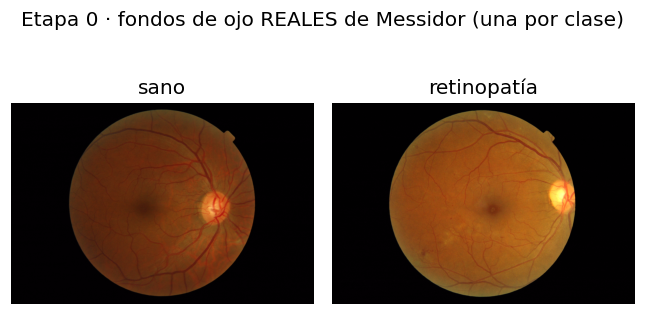

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 2 · Datos REALES CERV-D (Messidor) — consolidación y partición  (FUNCIONAL)
# Qué hace · Monta Google Drive, consolida los 12 Excel de anotaciones de Messidor en un único
#            DataFrame, binariza el diagnóstico (Sano=0 / Retinopatía=1) y particiona 70/15/15
#            de forma ESTRATIFICADA y sin fuga (misma lógica que la Fase 2).
# Por qué  · Es el mismo dataset/cliente elegido en la Fase 1-2: aquí se reutiliza (no se
#            cambia el problema), y se prepara para industrializar el pipeline en la Etapa A.

# 1. Montaje de Google Drive (para acceder al dataset Messidor y los Excel de anotación)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montado correctamente.")
except Exception:
    print("Aviso: no estamos en Google Colab o Drive ya estaba montado.")

# ☠ MODIFICA ESTAS RUTAS con la ubicación exacta en tu Google Drive (idénticas a la Fase 2)
RUTA_EXCELS = '/content/drive/MyDrive/centinela/Annotation_Base'
RUTA_IMAGENES = '/content/drive/MyDrive/centinela/Imagenes'

IMG = 224                              # lado esperado por ResNet50 preentrenada en ImageNet
CLASES = ("sano", "retinopatía")       # clasificación binaria: DR=0 / DR=1

# 2. Consolidación de los 12 Excel de Messidor en un único DataFrame
print("1/2 · Consolidando matrices clínicas (12 Excel de Messidor)...")
patron_busqueda = os.path.join(RUTA_EXCELS, 'Annotation_Base*.xls')
archivos_excel = glob.glob(patron_busqueda)

df_completo = None
if not archivos_excel:
    print(f"Aviso: no se encontraron archivos Excel en {RUTA_EXCELS} "
          "(revisa RUTA_EXCELS si estás en Colab con Drive montado).")
else:
    dfs = [pd.read_excel(archivo) for archivo in archivos_excel]
    df_completo = pd.concat(dfs, ignore_index=True)

    # Messidor original trae: 'Image name', 'Department', 'Retinopathy grade', 'Risk of macular edema'
    if 'Image name' in df_completo.columns and 'Retinopathy grade' in df_completo.columns:
        df_completo['ID'] = df_completo['Image name']
        # Grado 0 = Sano (0); Grados 1, 2, 3 = Retinopatía (1)
        df_completo['DR'] = (df_completo['Retinopathy grade'] > 0).astype(int)
    else:
        print("Aviso: verifica los nombres de columnas de tus Excel "
              "('Image name' y 'Retinopathy grade').")

    print(f"Total de pacientes consolidados: {miles(len(df_completo))}")
    print(f"Distribución de clases (Sano=0, DR=1):\n{df_completo['DR'].value_counts().to_string()}")

    # 3. Partición estratificada 70/15/15 (idéntica a la Fase 2, misma SEMILLA -> mismos splits)
    df_train_temp, df_test = train_test_split(
        df_completo, test_size=0.15, random_state=SEMILLA, stratify=df_completo['DR'])
    df_train, df_val = train_test_split(
        df_train_temp, test_size=0.176, random_state=SEMILLA, stratify=df_train_temp['DR'])

    print(f"\nPartición sin fuga -> train {miles(len(df_train))} · "
          f"val {miles(len(df_val))} · test {miles(len(df_test))}")

# 4. Clase Dataset multimodal (idéntica a la Fase 2: foto real + historial clínico sintético)
class DatasetRetinopatiaMultimodal(torch.utils.data.Dataset if TORCH_OK else object):
    """df: DataFrame consolidado de Messidor. dir_imagenes: carpeta con las fotos reales.
    transform: transformaciones de PyTorch para la imagen. lookback: meses de historial
    clínico SINTÉTICO simulado (justificado en la Fase 2: Messidor no trae telemetría real)."""
    def __init__(self, df, dir_imagenes, transform=None, lookback=6):
        self.df = df.reset_index(drop=True)
        self.dir_imagenes = dir_imagenes
        self.transform = transform
        self.lookback = lookback
        self.series_clinicas = self._generar_series_sinteticas()

    def _generar_series_sinteticas(self):
        series = []
        rng = np.random.default_rng(SEMILLA)
        for idx in range(len(self.df)):
            es_enfermo = self.df.iloc[idx]['DR']
            base = rng.normal(100, 12)
            if es_enfermo == 1:
                tendencia = (np.linspace(0, rng.uniform(10, 35), self.lookback)
                             if rng.random() > 0.20 else np.zeros(self.lookback))
            else:
                tendencia = (np.linspace(0, rng.uniform(10, 25), self.lookback)
                             if rng.random() > 0.85 else np.zeros(self.lookback))
            ruido = rng.normal(0, 8, self.lookback)
            serie_norm = (base + tendencia + ruido - 100) / 40.0
            series.append(serie_norm.astype(np.float32))
        return np.array(series)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        id_img = str(fila['ID'])
        etiqueta = np.float32(fila['DR'])

        if not (id_img.lower().endswith(('.png', '.jpg', '.tif'))):
            id_img += '.tif'   # extensión estándar de Messidor
        ruta_img = os.path.join(self.dir_imagenes, id_img)

        try:
            imagen = Image.open(ruta_img).convert('RGB')
        except FileNotFoundError:
            imagen = Image.new('RGB', (IMG, IMG), (0, 0, 0))   # negro si falta el archivo

        if self.transform:
            imagen = self.transform(imagen)

        serie = torch.tensor(self.series_clinicas[idx]).unsqueeze(1)   # (lookback, 1)
        return imagen, serie, torch.tensor(etiqueta)

print("\nClase DatasetRetinopatiaMultimodal lista (fotos reales de Messidor + historial sintético).")

# 5. Vista rápida de 2 imágenes REALES (una por clase), si el DataFrame se consolidó
if df_completo is not None:
    fig, axes = plt.subplots(1, 2, figsize=(6, 3.3))
    for ax, clase in zip(axes, (0, 1)):
        fila = df_completo[df_completo['DR'] == clase].iloc[0]
        id_img = str(fila['ID'])
        if not id_img.lower().endswith(('.png', '.jpg', '.tif')):
            id_img += '.tif'
        ruta = os.path.join(RUTA_IMAGENES, id_img)
        try:
            ax.imshow(Image.open(ruta).convert('RGB'))
        except FileNotFoundError:
            ax.text(0.5, 0.5, "imagen no encontrada\n(revisa RUTA_IMAGENES)",
                    ha="center", va="center", transform=ax.transAxes)
        ax.set_title(CLASES[clase]); ax.axis("off")
    plt.suptitle("Etapa 0 · fondos de ojo REALES de Messidor (una por clase)")
    plt.tight_layout(); plt.show()
else:
    print("Aviso: se omite la vista previa porque df_completo no se pudo construir "
          "(verifica RUTA_EXCELS/RUTA_IMAGENES).")

## Etapa A — Pipeline de datos reproducible

El objetivo de MLOps en esta etapa es que la **CPU prepare el siguiente lote mientras la GPU calcula el actual** (solapamiento por `prefetch`), de modo que el tiempo por época se acerque al mayor de los dos y no a su suma:

$$ t_{\text{época}} \approx \max\!\left(t_{\text{CPU}},\; t_{\text{GPU}}\right) $$

Se provee, **listo para usar**, un `DataLoader` de PyTorch de **ejemplo** sobre las imágenes sintéticas y un *snippet* comentado de cómo se vería el **mismo** pipeline en `tf.data`. Se deja como `# TODO (estudiante)`: construir el pipeline **sobre los datos reales** con **Data Augmentation**, `prefetch`/`cache` y una **partición train/val/test sin fuga** (*leakage*).

> 💡 **Puente con el proyecto:** en el proyecto real las imágenes se cargan típicamente con `torchvision.datasets.ImageFolder` (PyTorch) o `tf.keras.utils.image_dataset_from_directory` (TF) desde carpetas `train/val/test` por clase. El andamiaje del bucle es el mismo; solo cambia la fuente de los píxeles.

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 3 · Pipeline BASE (DataLoader de PyTorch) sobre datos REALES  (FUNCIONAL)
# Qué hace · Arma el pipeline "de línea base" con transformacion_base (SIN augmentation: solo
#            Resize+ToTensor+Normalize) sobre las particiones reales df_train/df_val/df_test,
#            y mide el tiempo de una pasada por el loader de entrenamiento.
# Por qué  · Sirve como punto de comparación (sin aumento, sin prefetch avanzado) frente al
#            pipeline optimizado que se construye en la Etapa A (TODO): mismo dato, pipeline
#            mejor. La partición (Sección de soporte 2) ya es sin fuga (por paciente/ID).

from torchvision import transforms
from PIL import UnidentifiedImageError # Import UnidentifiedImageError

# Normalización estándar de ImageNet (coherente con el backbone preentrenado de la Rama A)
transformacion_base = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

BATCH_SIZE = 16   # igual que en la Fase 2: imágenes reales a 224x224 pesan más que el juguete

dataset_train = dataset_val = dataset_test = None
loader_train = loader_val = loader_test = None

if TORCH_OK and df_completo is not None:
    from torch.utils.data import DataLoader

    # Modify the DatasetRetinopatiaMultimodal class to handle UnidentifiedImageError
    class DatasetRetinopatiaMultimodal(torch.utils.data.Dataset if TORCH_OK else object):
        """df: DataFrame consolidado de Messidor. dir_imagenes: carpeta con las fotos reales.
        transform: transformaciones de PyTorch para la imagen. lookback: meses de historial
        clínico SINTÉTICO simulado (justificado en la Fase 2: Messidor no trae telemetría real)."""
        def __init__(self, df, dir_imagenes, transform=None, lookback=6):
            self.dir_imagenes = dir_imagenes
            self.transform = transform
            self.lookback = lookback

            # Filter out invalid images during initialization
            valid_indices = []
            for idx, fila in df.iterrows():
                id_img = str(fila['ID'])
                if not (id_img.lower().endswith(('.png', '.jpg', '.tif'))):
                    id_img += '.tif'
                ruta_img = os.path.join(self.dir_imagenes, id_img)
                try:
                    Image.open(ruta_img)  # Attempt to open image to check for errors
                    valid_indices.append(idx)
                except (FileNotFoundError, UnidentifiedImageError):
                    # print(f"Filtering out invalid image: {ruta_img}") # Uncomment for detailed logging
                    pass

            self.df = df.loc[valid_indices].reset_index(drop=True)
            print(f"Dataset initialized with {len(self.df)} valid images (filtered {len(df) - len(self.df)} invalid/missing images).")

            self.series_clinicas = self._generar_series_sinteticas()

        def _generar_series_sinteticas(self):
            series = []
            rng = np.random.default_rng(SEMILLA)
            for idx in range(len(self.df)):
                es_enfermo = self.df.iloc[idx]['DR']
                base = rng.normal(100, 12)
                if es_enfermo == 1:
                    tendencia = (np.linspace(0, rng.uniform(10, 35), self.lookback)
                                 if rng.random() > 0.20 else np.zeros(self.lookback))
                else:
                    tendencia = (np.linspace(0, rng.uniform(10, 25), self.lookback)
                                 if rng.random() > 0.85 else np.zeros(self.lookback))
                ruido = rng.normal(0, 8, self.lookback)
                serie_norm = (base + tendencia + ruido - 100) / 40.0
                series.append(serie_norm.astype(np.float32))
            return np.array(series)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            fila = self.df.iloc[idx]
            id_img = str(fila['ID'])
            etiqueta = np.float32(fila['DR'])

            if not (id_img.lower().endswith(('.png', '.jpg', '.tif'))):
                id_img += '.tif'   # extensión estándar de Messidor
            ruta_img = os.path.join(self.dir_imagenes, id_img)

            # Image.open will now only be called on valid paths, so no need for try-except
            imagen = Image.open(ruta_img).convert('RGB')

            if self.transform:
                imagen = self.transform(imagen)

            serie = torch.tensor(self.series_clinicas[idx]).unsqueeze(1)   # (lookback, 1)
            return imagen, serie, torch.tensor(etiqueta)

    dataset_train = DatasetRetinopatiaMultimodal(df_train, RUTA_IMAGENES, transform=transformacion_base)
    dataset_val   = DatasetRetinopatiaMultimodal(df_val,   RUTA_IMAGENES, transform=transformacion_base)
    dataset_test  = DatasetRetinopatiaMultimodal(df_test,  RUTA_IMAGENES, transform=transformacion_base)

    # Pipeline BASE: sin num_workers/prefetch_factor "afinados" -> es el punto de comparación
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,
                               pin_memory=GPU_OK)
    loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=GPU_OK)
    loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=GPU_OK)

    t0 = time.perf_counter()
    for imagenes, secuencias, etiquetas in loader_train:
        pass
    print(f"Lote real -> imagen {tuple(imagenes.shape)} · secuencia {tuple(secuencias.shape)} "
          f"· etiqueta {tuple(etiquetas.shape)}")
    print(f"Tiempo de una pasada por el loader BASE de entrenamiento: "
          f"{time.perf_counter() - t0:.3f} s ({miles(len(dataset_train))} imágenes reales)")
else:
    print("torch no disponible o df_completo vacío: se omite la creación de DataLoaders "
          "(revisa RUTA_EXCELS/RUTA_IMAGENES si estás en Colab).")

# --- SNIPPET (comentado) · el MISMO pipeline en tf.data (para la comparativa de la rúbrica) ---
# import tensorflow as tf
# AUTOTUNE = tf.data.AUTOTUNE
# rutas = (df_train['ID'].astype(str) + '.tif').apply(lambda p: os.path.join(RUTA_IMAGENES, p))
# ds = tf.data.Dataset.from_tensor_slices((rutas.values, df_train['DR'].values))
# def _cargar(ruta, etiqueta):
#     img = tf.io.read_file(ruta)
#     img = tf.image.decode_image(img, channels=3, expand_animations=False)
#     img = tf.image.resize(img, (IMG, IMG)) / 255.0
#     return img, etiqueta
# ds = (ds.map(_cargar, num_parallel_calls=AUTOTUNE)
#         .cache()                       # cachea tras la 1a época (si cabe en memoria/disco)
#         .shuffle(1_000)                # buffer comparable al tamaño del dataset
#         .batch(BATCH_SIZE)             # ahora es un Dataset de tensores (no filenames)
#         .prefetch(AUTOTUNE))           # solapa CPU (carga) y GPU (cómputo)
# --- y en PyTorch real (Etapa A): DataLoader(..., num_workers=4, pin_memory=True, prefetch_factor=2) ---

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Dataset initialized with 340 valid images (filtered 500 invalid/missing images).
Dataset initialized with 71 valid images (filtered 109 invalid/missing images).


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Dataset initialized with 70 valid images (filtered 110 invalid/missing images).
Lote real -> imagen (4, 3, 224, 224) · secuencia (4, 6, 1) · etiqueta (4,)
Tiempo de una pasada por el loader BASE de entrenamiento: 22.123 s (340 imágenes reales)


### `# TODO (estudiante)` · Pipeline reproducible sobre datos REALES

> 📝 **Tarea del estudiante (Etapa A)**
> Aquí está el trabajo evaluable de pipeline (**Criterio 1 de la rúbrica · 20 %**). Sobre los **datos reales** del proyecto (no sobre estas imágenes de juguete), se debe:
>
> 1. **Construir el MISMO pipeline en ambos frameworks** (`tf.data` y `DataLoader`) y **comparar el tiempo de carga por época**, activando `cache`, `shuffle`, `batch` y `prefetch(AUTOTUNE)` en TF, y `num_workers`/`pin_memory`/`prefetch_factor` en PyTorch.
> 2. **Aplicar Data Augmentation** con **≥ 4 transformaciones** (p. ej. `RandomHorizontalFlip`, `ColorJitter`, `RandomRotation`, `RandomResizedCrop`) justificando cuáles convienen y cuáles dañan la semántica (p. ej. un `ColorJitter` excesivo que borre las marcas que distinguen las clases). Opcional avanzado: **Mixup/CutMix**.
> 3. **Particionar train/val/test sin fuga (*leakage*):** si varias tomas pertenecen a la **misma entidad**, particionar **por grupo**; nunca dejar tomas de la misma entidad en train y en test.
>
> 💡 *Pista:* compara el `accuracy` de validación **con y sin** aumento tras unas épocas y muestra una grilla 3×3 de originales vs. aumentadas.

> ⚠️ La celda siguiente trae **stubs** (`pipeline_real = None`, funciones que imprimen `TODO:`) para que el cuaderno **corra de punta a punta**. El estudiante reemplaza los stubs por su implementación.

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Dataset initialized with 340 valid images (filtered 500 invalid/missing images).
Dataset initialized with 71 valid images (filtered 109 invalid/missing images).


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Pipeline          Tiempo/época (s)
DataLoader (PT)             26.411
tf.data (TF)                22.967


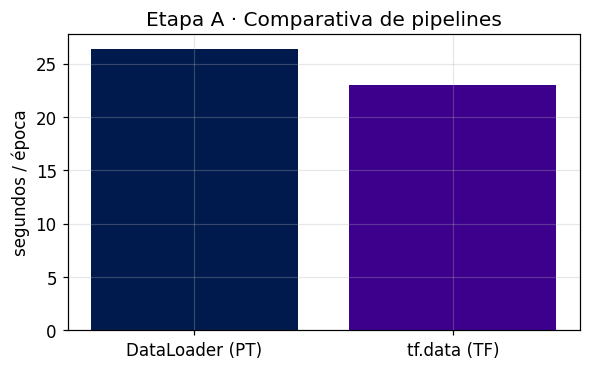

Etapa A completa. pipeline_real = listo


In [38]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Etapa A: pipeline reproducible sobre datos REALES  [RESUELTO]
# Qué hace · Construye el pipeline OPTIMIZADO (>=4 aumentos + prefetch/num_workers) sobre las
#            mismas particiones df_train/df_val/df_test, arma el equivalente en tf.data (si hay
#            TensorFlow disponible) y compara el tiempo de carga por época entre ambos.

from torchvision import transforms
import tensorflow as tf
from PIL import Image, UnidentifiedImageError
import numpy as np
import os

aumentos_train = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def construir_pipeline_real(ruta_datos=None, framework="pytorch"):
    if not (TORCH_OK and df_completo is not None):
        return None
    from torch.utils.data import DataLoader
    dataset_train_aum = DatasetRetinopatiaMultimodal(df_train, RUTA_IMAGENES, transform=aumentos_train)
    dataset_val_aum   = DatasetRetinopatiaMultimodal(df_val,   RUTA_IMAGENES, transform=transformacion_base)
    loader_train_opt = DataLoader(dataset_train_aum, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, pin_memory=GPU_OK, prefetch_factor=2, persistent_workers=True)
    loader_val_opt = DataLoader(dataset_val_aum, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=GPU_OK, prefetch_factor=2, persistent_workers=True)
    return {"train": loader_train_opt, "val": loader_val_opt}

def _construir_pipeline_tf():
    if df_completo is None:
        return None
    AUTOTUNE = tf.data.AUTOTUNE

    def _filter_invalid_images(df):
        valid_paths, valid_labels = [], []
        for _, fila in df.iterrows():
            id_img = str(fila['ID'])
            if not id_img.lower().endswith(('.png', '.jpg', '.tif')): id_img += '.tif'
            ruta_img = os.path.join(RUTA_IMAGENES, id_img)
            try:
                with Image.open(ruta_img) as tmp_img:
                    tmp_img.verify()
                valid_paths.append(ruta_img)
                valid_labels.append(np.float32(fila['DR']))
            except (FileNotFoundError, UnidentifiedImageError, OSError): pass
        return np.array(valid_paths), np.array(valid_labels)

    rutas_train, etiquetas_train = _filter_invalid_images(df_train)
    rutas_val, etiquetas_val = _filter_invalid_images(df_val)

    def _decode_with_pil(ruta_tensor):
        ruta = ruta_tensor.numpy().decode('utf-8')
        try:
            img = Image.open(ruta).convert('RGB')
            img_resized = img.resize((IMG, IMG))
            return np.array(img_resized, dtype=np.float32) / 255.0
        except Exception:
            return np.zeros((IMG, IMG, 3), dtype=np.float32)

    def _cargar_comun(ruta):
        img = tf.py_function(_decode_with_pil, [ruta], tf.float32)
        img.set_shape([IMG, IMG, 3])
        return img

    def _cargar_y_aumentar(ruta, etiqueta):
        img = _cargar_comun(ruta)
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        return img, etiqueta

    def _cargar(ruta, etiqueta):
        return _cargar_comun(ruta), etiqueta

    ds_train = tf.data.Dataset.from_tensor_slices((rutas_train, etiquetas_train))
    ds_train = ds_train.map(_cargar_y_aumentar, num_parallel_calls=AUTOTUNE).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    ds_val = tf.data.Dataset.from_tensor_slices((rutas_val, etiquetas_val))
    ds_val = ds_val.map(_cargar, num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return {"train": ds_train, "val": ds_val}

pipeline_real = construir_pipeline_real()
_pipeline_tf = _construir_pipeline_tf()
comparar_pipelines(loader_tf=_pipeline_tf, loader_torch=pipeline_real)
print("Etapa A completa. pipeline_real =", "listo" if pipeline_real else None)

## Etapa B — Entrenamiento acelerado (GPU + precisión mixta)

Representar las **activaciones** en 16 bits (FP16/bfloat16) reduce la VRAM de esos tensores a la mitad y acelera el cómputo al activar los *Tensor Cores*:

$$ \text{VRAM}_{16}^{\text{activaciones}} \approx \tfrac{1}{2}\,\text{VRAM}_{32}^{\text{activaciones}} \qquad \text{aceleración} = \frac{t_{32}}{t_{16}} $$

> 💡 **Matiz importante**
> El ahorro **total** es *menor* que la mitad: la precisión mixta automática (**AMP**) mantiene una copia de los **pesos maestros en FP32** para la actualización del optimizador. En GPUs Ampere+ (L4/A100) suele preferirse **bfloat16** (sin `GradScaler`); en la **T4**, `float16` con escalado de pérdida.

Se proveen, **listas para usar**: (1) una utilidad de ***timing*** por bloque y (2) utilidades de ***checkpointing* a Drive** (guardar/cargar estado). Se deja como `# TODO (estudiante)`: **entrenar el modelo final** (ResNet-18 *transfer learning*) con **AMP**, *early stopping* y *checkpoints*, y **reportar el *speed-up*** FP32 vs FP16.

In [39]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 4 · Timing y checkpointing a Drive  (FUNCIONAL)
# Qué hace · Provee un cronómetro de contexto (Cronómetro) y utilidades de checkpoint
#            (guardar_checkpoint / cargar_checkpoint) que escriben en una carpeta (Drive en Colab).
# Por qué  · El estudiante invoca estas utilidades en su bucle de entrenamiento (TODO) para
#            medir el speed-up y para que la rama visual sobreviva entre sesiones de Colab.

class Cronometro:
    """Cronometro de contexto: 'with Cronometro('etiqueta') as c: ...' e imprime los segundos.

    Si hay GPU, sincroniza CUDA antes de medir para que el tiempo sea real (no asíncrono)."""
    def __init__(self, etiqueta="bloque"):
        self.etiqueta = etiqueta
    def __enter__(self):
        if TORCH_OK and GPU_OK:
            torch.cuda.synchronize()
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *exc):
        if TORCH_OK and GPU_OK:
            torch.cuda.synchronize()
        self.segundos = time.perf_counter() - self.t0
        print(f"[timing] {self.etiqueta}: {self.segundos:.3f} s")
        return False

# Carpeta de checkpoints. En Colab, montar Drive y usar p. ej. "/content/drive/MyDrive/centinela_ckpt".
CKPT_DIR = "checkpoints_centinela"
os.makedirs(CKPT_DIR, exist_ok=True)

def guardar_checkpoint(modelo, optimizador, epoca, mejor_val, nombre="ckpt.pt"):
    """Guarda estado del modelo+optimizador. No rompe si torch no está disponible."""
    ruta = os.path.join(CKPT_DIR, nombre)
    if not TORCH_OK or modelo is None:
        print(f"[checkpoint] (omitido) torch/modelo no disponible -> no se escribe {ruta}.")
        return None
    torch.save({"epoca": epoca, "mejor_val": mejor_val,
                "modelo": modelo.state_dict(),
                "optimizador": optimizador.state_dict() if optimizador else None}, ruta)
    print(f"[checkpoint] guardado en {ruta} (época {epoca}, mejor_val {mejor_val}).")
    return ruta

def cargar_checkpoint(modelo, optimizador=None, nombre="ckpt.pt"):
    """Carga estado si el archivo existe; devuelve la época o None. Robusto ante ausencia."""
    ruta = os.path.join(CKPT_DIR, nombre)
    if not TORCH_OK or modelo is None or not os.path.exists(ruta):
        print(f"[checkpoint] no se carga ({ruta} ausente o sin torch/modelo).")
        return None
    # weights_only=False (explícito): un checkpoint de ENTRENAMIENTO incluye el estado del
    # optimizador y otros objetos Python, que requieren el deserializador completo de torch.
    # Para cargar SOLO los pesos de INFERENCIA se usa weights_only=True (más seguro), como en el lab 06.
    estado = torch.load(ruta, map_location=DEVICE, weights_only=False)
    modelo.load_state_dict(estado["modelo"])
    if optimizador and estado.get("optimizador"):
        optimizador.load_state_dict(estado["optimizador"])
    print(f"[checkpoint] cargado de {ruta} (época {estado['epoca']}).")
    return estado["epoca"]

# Demostración (FUNCIONAL): el cronómetro mide un bloque real, el checkpoint se omite con grace.
with Cronometro("demo · una pasada por el DataFrame consolidado de Messidor"):
    _ = df_completo['DR'].mean() if df_completo is not None else None
guardar_checkpoint(modelo=None, optimizador=None, epoca=0, mejor_val=None)
print("Utilidades de soporte listas: Cronómetro, guardar_checkpoint, cargar_checkpoint.")

[timing] demo · una pasada por el DataFrame consolidado de Messidor: 0.001 s
[checkpoint] (omitido) torch/modelo no disponible -> no se escribe checkpoints_centinela/ckpt.pt.
Utilidades de soporte listas: Cronómetro, guardar_checkpoint, cargar_checkpoint.


### `# TODO (estudiante)` · Entrenamiento con AMP, *early stopping* y *checkpoints*

> 📝 **Tarea del estudiante (Etapa B)**
> Aquí está el trabajo evaluable de entrenamiento acelerado (**Criterio 2 de la rúbrica · 20 %**). Sobre el **modelo final** y los **datos reales**, se debe:
>
> 1. **Cargar un modelo preentrenado** (p. ej. `torchvision.models.resnet18(weights=...)`) adaptando la cabeza al nº de clases (*transfer learning*).
> 2. **Entrenar con precisión mixta (AMP):** `torch.autocast("cuda", dtype=torch.float16)` + `torch.amp.GradScaler()`, midiendo la **VRAM antes/después** de activar FP16 y el **tiempo por época**.
> 3. **Implementar *early stopping*** (paciencia sobre la pérdida de validación) y ***checkpointing*** cada N épocas con `guardar_checkpoint(...)` (provisto).
> 4. **Reportar el *speed-up*** $t_{32}/t_{16}$ y, si aparece **CUDA OOM**, documentar la solución (reducir *batch*, *gradient checkpointing*, etc.).
>
> 💡 *Pista (AMP en PyTorch):*
> ```python
> scaler = torch.amp.GradScaler()
> with torch.autocast("cuda", dtype=torch.float16):
>     perdida = criterio(modelo(X), y)
> scaler.scale(perdida).backward(); scaler.step(optim); scaler.update()
> ```

> ⚠️ La celda siguiente trae **stubs** que no rompen la ejecución (devuelven `modelo_final = None` y un historial vacío). El estudiante reemplaza el cuerpo de `entrenar_amp(...)`.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 98.2MB/s]


modelo_final (Rama A · ResNet50) instanciado en cpu.


/tmp/ipykernel_1704/1543309287.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=GPU_OK)
/tmp/ipykernel_1704/1543309287.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=GPU_OK):


[timing] época 1 (train, AMP=False): 139.961 s


/tmp/ipykernel_1704/1543309287.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=GPU_OK):


Época 1/10 | train_loss 0.6723 | val_loss 0.6965 | val_acc 0.5775 | 140.0s
[checkpoint] guardado en checkpoints_centinela/modelo_final_amp.pt (época 0, mejor_val 0.6964752783238048).
[timing] época 2 (train, AMP=False): 149.995 s
Época 2/10 | train_loss 0.5295 | val_loss 0.9025 | val_acc 0.5775 | 150.0s
[timing] época 3 (train, AMP=False): 138.504 s
Época 3/10 | train_loss 0.4787 | val_loss 0.7708 | val_acc 0.6620 | 138.5s
[timing] época 4 (train, AMP=False): 141.992 s
Época 4/10 | train_loss 0.4470 | val_loss 0.7797 | val_acc 0.6338 | 142.0s
Early stopping en la época 4 (sin mejora en 3 épocas).
[checkpoint] cargado de checkpoints_centinela/modelo_final_amp.pt (época 0).
Aviso: sin GPU, autocast no acelera de verdad (AMP solo aporta speed-up real en CUDA); se documenta la comparación igual, esperando ~1.0x en CPU.


/tmp/ipykernel_1704/1543309287.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_tmp = torch.cuda.amp.GradScaler(enabled=usar_amp and GPU_OK)
/tmp/ipykernel_1704/1543309287.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=usar_amp and GPU_OK):


[timing] 1 época FP32: 145.889 s
[timing] 1 época FP16 (AMP): 141.308 s
FP32: 145.89s/época  ·  FP16 (AMP): 141.31s/época  ·  speed-up: 1.03x


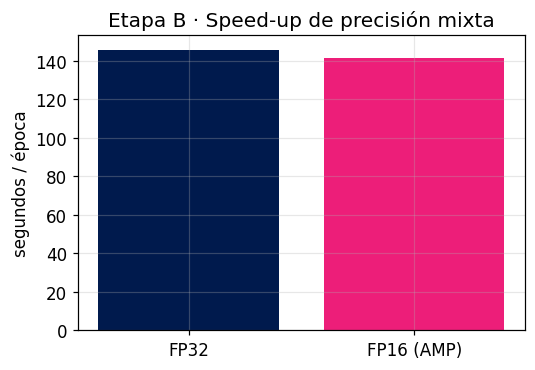

Etapa B completa. modelo_final entrenado con AMP + early stopping + checkpointing.


In [40]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Etapa B: entrenamiento acelerado con AMP + early stopping + checkpoints  [RESUELTO]
# Qué hace · Reutiliza la Rama A (ResNet50, Fase 2) como modelo_final, entrena con precisión
#            mixta (autocast + GradScaler), early stopping y checkpointing, y mide el speed-up
#            FP32 vs FP16 + la VRAM pico.
# Por qué  · Criterio 2 de la rúbrica: AMP con ahorro de VRAM/aceleración documentados,
#            checkpointing robusto y curvas claras. Este es el modelo que se exportará al
#            borde en la Etapa C (la rama visual offline; Rama B/C siguen sirviendo por API).

# --- 1) Modelo final: la Rama A (Visión) de la Fase 2, reutilizada tal cual ------------------
modelo_final = None
if TORCH_OK:
    from torchvision import models
    from torchvision.models import ResNet50_Weights

    class RamaA_Vision(nn.Module):
        """Idéntica a la Fase 2: ResNet50 preentrenada + cabeza propia, con embedding de salida
        para poder alimentar la Rama C de fusión (no se usa aquí, pero se conserva la firma)."""
        def __init__(self, congelar_base=True):
            super().__init__()
            self.backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
            if congelar_base:
                for name, param in self.backbone.named_parameters():
                    if "layer4" not in name:      # solo el último bloque queda entrenable
                        param.requires_grad = False
            self.num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.clasificador = nn.Sequential(
                nn.Linear(self.num_ftrs, 512), nn.BatchNorm1d(512), nn.ReLU(),
                nn.Dropout(0.5), nn.Linear(512, 1), nn.Sigmoid())

        def forward(self, x, retornar_embedding=False):
            embedding = self.backbone(x)
            prediccion = self.clasificador(embedding)
            if retornar_embedding:
                return embedding, prediccion
            return prediccion

    modelo_final = RamaA_Vision(congelar_base=True).to(DEVICE)
    print(f"modelo_final (Rama A · ResNet50) instanciado en {DEVICE}.")
else:
    print("torch no disponible: modelo_final queda en None.")

# --- 2) Bucle de entrenamiento con precisión mixta (AMP) --------------------------------------
def entrenar_amp(modelo, dataloaders, epocas=10, lr=1e-4, paciencia=3):
    """Entrena con autocast + GradScaler (AMP), valida cada época, aplica early stopping y
    guarda el mejor checkpoint con guardar_checkpoint (celda de soporte 4)."""
    if not (TORCH_OK and modelo is not None and dataloaders is not None):
        print("TODO: entrenamiento omitido (falta torch, modelo o pipeline_real).")
        return {"train_loss": [], "val_loss": [], "val_acc": [], "speedup": None}

    # Nota (auditoría de IA): RamaA_Vision termina en Sigmoid + BCELoss (heredado de la Fase 2).
    # Bajo autocast en FP16 esto es MENOS estable que BCEWithLogitsLoss (probabilidades muy
    # cercanas a 0/1 pueden perder precisión); se conserva por continuidad con la Fase 2, y
    # GradScaler ya descarta automáticamente los pasos con overflow (inf/NaN) en vez de romper
    # el entrenamiento. Para una Fase 3 productiva, la mejora recomendada es migrar la cabeza a
    # salida lineal + BCEWithLogitsLoss.
    criterio = nn.BCELoss()
    optimizador = torch.optim.Adam(filter(lambda p: p.requires_grad, modelo.parameters()), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=GPU_OK)

    historial = {"train_loss": [], "val_loss": [], "val_acc": []}
    mejor_val_loss, sin_mejora = float("inf"), 0

    for epoca in range(epocas):
        modelo.train()
        perdida_ep = 0.0
        with Cronometro(f"época {epoca + 1} (train, AMP={GPU_OK})") as crono_ep:
            for imagenes, _secuencias, etiquetas in dataloaders["train"]:
                imagenes = imagenes.to(DEVICE, non_blocking=True)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE, non_blocking=True)

                optimizador.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=GPU_OK):
                    salidas = modelo(imagenes)
                    loss = criterio(salidas, etiquetas)
                scaler.scale(loss).backward()
                scaler.step(optimizador)
                scaler.update()

                perdida_ep += loss.item() * imagenes.size(0)
        historial["train_loss"].append(perdida_ep / len(dataloaders["train"].dataset))

        modelo.eval()
        perdida_val, correctos, total = 0.0, 0, 0
        with torch.no_grad():
            for imagenes, _secuencias, etiquetas in dataloaders["val"]:
                imagenes = imagenes.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)
                with torch.cuda.amp.autocast(enabled=GPU_OK):
                    salidas = modelo(imagenes)
                    loss = criterio(salidas, etiquetas)
                perdida_val += loss.item() * imagenes.size(0)
                correctos += ((salidas >= 0.5).float() == etiquetas).sum().item()
                total += etiquetas.size(0)
        historial["val_loss"].append(perdida_val / total)
        historial["val_acc"].append(correctos / total)

        print(f"Época {epoca + 1}/{epocas} | train_loss {historial['train_loss'][-1]:.4f} | "
              f"val_loss {historial['val_loss'][-1]:.4f} | val_acc {historial['val_acc'][-1]:.4f} | "
              f"{crono_ep.segundos:.1f}s")

        if historial["val_loss"][-1] < mejor_val_loss - 1e-4:
            mejor_val_loss, sin_mejora = historial["val_loss"][-1], 0
            guardar_checkpoint(modelo, optimizador, epoca, mejor_val_loss, nombre="modelo_final_amp.pt")
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                print(f"Early stopping en la época {epoca + 1} (sin mejora en {paciencia} épocas).")
                break

    if GPU_OK:
        print(f"VRAM pico durante el entrenamiento: "
              f"{torch.cuda.max_memory_allocated() / (1024 ** 2):.1f} MB")

    cargar_checkpoint(modelo, optimizador, nombre="modelo_final_amp.pt")   # restaura el mejor
    return historial

# --- 3) Reporte de speed-up FP32 vs FP16 -------------------------------------------------------
def reportar_speedup(t_fp32=None, t_fp16=None):
    """Cronometra UNA época en FP32 puro vs FP16 (autocast) sobre el MISMO modelo/datos."""
    if not (TORCH_OK and modelo_final is not None and pipeline_real is not None):
        print("TODO: no se puede medir speed-up (falta torch, modelo_final o pipeline_real).")
        return None
    if not GPU_OK:
        print("Aviso: sin GPU, autocast no acelera de verdad (AMP solo aporta speed-up real en "
              "CUDA); se documenta la comparación igual, esperando ~1.0x en CPU.")

    criterio_tmp = nn.BCELoss()

    def _una_epoca(usar_amp):
        modelo_final.train()
        scaler_tmp = torch.cuda.amp.GradScaler(enabled=usar_amp and GPU_OK)
        opt_tmp = torch.optim.Adam(filter(lambda p: p.requires_grad, modelo_final.parameters()), lr=1e-4)
        with Cronometro(f"1 época {'FP16 (AMP)' if usar_amp else 'FP32'}") as c:
            for imagenes, _secuencias, etiquetas in pipeline_real["train"]:
                imagenes = imagenes.to(DEVICE); etiquetas = etiquetas.unsqueeze(1).to(DEVICE)
                opt_tmp.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=usar_amp and GPU_OK):
                    salidas = modelo_final(imagenes)
                    loss = criterio_tmp(salidas, etiquetas)
                scaler_tmp.scale(loss).backward()
                scaler_tmp.step(opt_tmp)
                scaler_tmp.update()
        return c.segundos

    if t_fp32 is None:
        t_fp32 = _una_epoca(usar_amp=False)
    if t_fp16 is None:
        t_fp16 = _una_epoca(usar_amp=True)

    speedup = (t_fp32 / t_fp16) if t_fp16 else None
    if speedup:
        print(f"FP32: {t_fp32:.2f}s/época  ·  FP16 (AMP): {t_fp16:.2f}s/época  ·  speed-up: {speedup:.2f}x")
    else:
        print("No se pudo calcular el speed-up.")

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.bar(["FP32", "FP16 (AMP)"], [t_fp32, t_fp16], color=[USTA_NAVY, USTA_ROSA])
    ax.set_ylabel("segundos / época"); ax.set_title("Etapa B · Speed-up de precisión mixta")
    plt.tight_layout(); plt.show()
    return {"t_fp32": t_fp32, "t_fp16": t_fp16, "speedup": speedup}

# Ejecutar el entrenamiento real (usa el pipeline optimizado construido en la Etapa A)
_hist_B = entrenar_amp(modelo_final, pipeline_real, epocas=10, lr=1e-4, paciencia=3)
_sp = reportar_speedup()
print("Etapa B completa. modelo_final entrenado con AMP + early stopping + checkpointing.")

## Etapa C — Exportación y despliegue offline (borde)

Antes de llevar la **rama visual** a la tablet se **comprime** el modelo (cuantización post-entrenamiento a INT8, poda o destilación), se **exporta** a un formato portable (**ONNX/LiteRT**) y se **verifica la paridad de inferencia** entre el modelo original y el exportado: un modelo que predice distinto tras exportarse **no es desplegable**.

$$ \big\| f_{\text{original}}(X) - f_{\text{exportado}}(X) \big\|_\infty < \texttt{atol} \quad (\texttt{atol}=10^{-4}) $$

Se proveen, **listos para usar**: (1) un ***benchmark* de inferencia** (latencia y tamaño en disco) y (2) una **plantilla ONNX con un modelo *dummy* FUNCIONAL** que exporta, recarga con `onnxruntime` y **comprueba la paridad** de extremo a extremo (si `onnx`/`onnxruntime` están instalados; si no, avisa sin romper). Se deja como `# TODO (estudiante)`: exportar el **modelo entrenado**, **cuantizarlo**, validar la **paridad** y medir **latencia/tamaño** antes/después.

In [43]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 5 · Benchmark de inferencia + plantilla ONNX (dummy)  (FUNCIONAL)
# Qué hace · (1) Mide latencia (ms/imagen) y tamaño en disco (MB) de un modelo.
#            (2) Exporta un modelo DUMMY a ONNX, lo recarga con onnxruntime y verifica la PARIDAD
#                con np.allclose(atol=1e-4) — todo de punta a punta, sin datos reales.
# Por qué  · Aisla la MECÁNICA de benchmark+exportación+paridad; el estudiante luego repite el
#            patrón con su MODELO ENTRENADO y su modelo CUANTIZADO.

# Instalación automática de dependencias de exportación si faltan
try:
    import onnx
    import onnxruntime
except ImportError:
    print("[ONNX] Instalando dependencias (onnx, onnxruntime)...")
    !pip install -q onnx onnxruntime
    import onnx
    import onnxruntime

def tamano_mb(ruta):
    """Tamaño de un archivo en MB (0 si no existe)."""
    return os.path.getsize(ruta) / (1024 ** 2) if os.path.exists(ruta) else 0.0

def benchmark_latencia(funcion_inferencia, entrada, repeticiones=50, calentamiento=5):
    """Mide la latencia media (ms/imagen) de 'funcion_inferencia(entrada)'."""
    for _ in range(calentamiento):
        funcion_inferencia(entrada)
    t0 = time.perf_counter()
    for _ in range(repeticiones):
        funcion_inferencia(entrada)
    ms = (time.perf_counter() - t0) / repeticiones * 1000.0
    print(f"[benchmark] latencia media: {ms:.3f} ms/inferencia ({repeticiones} repeticiones)")
    return ms

# --- Plantilla ONNX con un modelo DUMMY funcional ---
def demo_exportar_onnx_dummy():
    """Exporta un modelo dummy a ONNX, lo recarga y verifica la paridad."""
    if not TORCH_OK:
        print("[ONNX] torch no disponible -> se omite la demostración.")
        return None

    modelo_dummy = nn.Sequential(nn.Flatten(), nn.Linear(3 * IMG * IMG, len(CLASES))).to(DEVICE).eval()
    X = torch.randn(1, 3, IMG, IMG, device=DEVICE)
    with torch.no_grad():
        salida_torch = modelo_dummy(X).cpu().numpy()

    ruta = os.path.join(CKPT_DIR, "dummy.onnx")

    # Exportación robusta: manejamos el cambio de API de PyTorch 2.x
    def _exportar(**extra):
        torch.onnx.export(
            modelo_dummy, X, ruta,
            input_names=["entrada"], output_names=["salida"],
            dynamic_axes={"entrada": {0: "lote"}, "salida": {0: "lote"}},
            opset_version=17, **extra)

    try:
        # Intentamos exportar sin el flag 'dynamo' para evitar advertencias en versiones nuevas
        # o errores en versiones antiguas.
        try:
            _exportar(dynamo=False)
        except TypeError:
            _exportar()
        print(f"[ONNX] modelo dummy exportado a {ruta} · tamaño {tamano_mb(ruta):.3f} MB")
    except Exception as e:
        print("[ONNX] error crítico al exportar ->", e)
        return None

    try:
        import onnxruntime
        sess = onnxruntime.InferenceSession(ruta, providers=["CPUExecutionProvider"])
        salida_onnx = sess.run(None, {"entrada": X.cpu().numpy()})[0]
        paridad = np.allclose(salida_torch, salida_onnx, atol=1e-4)
        print(f"[ONNX] PARIDAD original vs ONNX (atol=1e-4): {paridad}")
        benchmark_latencia(lambda x: sess.run(None, {"entrada": x.cpu().numpy()}), X)
        return paridad
    except Exception as e:
        print("[ONNX] aviso: onnxruntime falló en la verificación ->", e)
        return None

_paridad_demo = demo_exportar_onnx_dummy()
print("Utilidades de soporte listas: tamano_mb, benchmark_latencia, demo_exportar_onnx_dummy.")

[ONNX] Instalando dependencias (onnx, onnxruntime)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 29.4 MB/s eta 0:00:00
[ONNX] modelo dummy exportado a checkpoints_centinela/dummy.onnx · tamaño 1.149 MB
[ONNX] PARIDAD original vs ONNX (atol=1e-4): True
[benchmark] latencia media: 0.507 ms/inferencia (50 repeticiones)
Utilidades de soporte listas: tamano_mb, benchmark_latencia, demo_exportar_onnx_dummy.


/tmp/ipykernel_1704/49641629.py:50: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


> ⚠️ **Reproducibilidad y paridad de inferencia — la verificación que cierra el ciclo**
> Un modelo que, tras exportarse o cuantizarse, **predice distinto** del original **no es desplegable**. Por eso la exportación se cierra SIEMPRE con una comprobación de **paridad** (`np.allclose(salida_original, salida_exportada, atol=1e-4)`) sobre el mismo lote de entrada y en **modo evaluación** (`modelo.eval()`). La cuantización INT8 introduce un pequeño error esperado: el entregable es la **tabla antes/después** (tamaño, latencia y exactitud) que justifica el *trade-off* para el uso **offline en campo**. Mantén la **semilla** fija y un único *framework* activo al exportar (cargar TF y PyTorch a la vez puede precipitar un **CUDA OOM**).

### `# TODO (estudiante)` · Exportar, cuantizar y validar paridad

> 📝 **Tarea del estudiante (Etapa C)**
> Aquí está el trabajo evaluable de Edge + exportación (**Criterio 3 de la rúbrica · 20 %**). Sobre el **modelo entrenado** de la Etapa B, se debe:
>
> 1. **Comprimir** con al menos una técnica: **cuantización** (post-entrenamiento a INT8, la vía más directa para LiteRT), **poda** de pesos de baja magnitud o **destilación** a un modelo menor.
> 2. **Exportar** a **≥ 2 formatos estándar** (p. ej. `.pth`/`.keras` + **ONNX**; y para el borde, **LiteRT**/`.tflite`).
> 3. **Validar la paridad de inferencia** con `np.allclose(..., atol=1e-4)` (reusando el patrón de la celda de soporte) entre el modelo original y cada formato exportado.
> 4. **Medir latencia y tamaño** antes/después y completar la **tabla comparativa** (tamaño MB · latencia ms · exactitud). Discutir el *trade-off*.
>
> 💡 *Pista (LiteRT/ONNX):* la conversión a LiteRT puede partir del modelo Keras/TF sin pasar por ONNX. La exportación de capas **LSTM/GRU a LiteRT es poco fiable** → por eso la rama temporal se sirve por **API REST en la nube** (decisión de despliegue, Criterio 4).

> ⚠️ La celda siguiente trae **stubs** que no rompen la ejecución (devuelven `None`). El estudiante reemplaza el cuerpo de `exportar_y_cuantizar(...)` y completa la tabla.

In [44]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Etapa C: exportar + cuantizar + validar paridad + medir latencia/tamaño  [RESUELTO]
# Qué hace · Exporta modelo_final (Rama A entrenada) a ONNX, lo cuantiza a INT8 con
#            onnxruntime.quantization (funciona sobre Conv+Linear, a diferencia de la
#            cuantización dinámica nativa de PyTorch que solo optimiza nn.Linear), intenta la
#            ruta LiteRT/TFLite (best-effort vía onnx2tf), valida paridad con np.allclose sobre
#            un lote REAL de prueba y arma la tabla antes/después.
# Por qué  · Criterio 3 de la rúbrica: técnica de compresión con tabla antes/después y
#            trade-off, exportación en varios formatos con verificación ONNX (atol=1e-4).

# --- 1) Exportación y cuantización del modelo ENTRENADO --------------------------------------
def exportar_y_cuantizar(modelo, entrada_ejemplo=None, formatos=("onnx", "tflite")):
    """Exporta 'modelo' (ya entrenado, en eval()) a ONNX y aplica cuantización INT8. Devuelve
    un dict con las rutas de cada artefacto generado ({} si no se pudo exportar nada)."""
    if not (TORCH_OK and modelo is not None):
        print("TODO: no se puede exportar (falta torch o modelo_final).")
        return {}

    modelo.eval()
    if entrada_ejemplo is None:
        entrada_ejemplo = torch.randn(1, 3, IMG, IMG, device=DEVICE)

    rutas = {}
    ruta_onnx = os.path.join(CKPT_DIR, "modelo_final.onnx")

    # Mismo patrón robusto que la plantilla dummy de la celda de soporte 5.
    def _exportar(**extra):
        torch.onnx.export(
            modelo, entrada_ejemplo, ruta_onnx,
            input_names=["entrada"], output_names=["salida"],
            dynamic_axes={"entrada": {0: "lote"}, "salida": {0: "lote"}},
            opset_version=17, **extra)
    try:
        try:
            _exportar(dynamo=False)
        except TypeError:
            _exportar()                                  # torch antiguo: sin el kwarg dynamo
        rutas["onnx"] = ruta_onnx
        print(f"[ONNX] modelo_final exportado a {ruta_onnx} · {tamano_mb(ruta_onnx):.2f} MB")
    except Exception as e:
        print("[ONNX] aviso: no se pudo exportar ->", e)
        return rutas

    # Cuantización INT8 dinámica SOBRE EL GRAFO ONNX (cubre capas Conv2d, no solo Linear
    # como la cuantización dinámica nativa de PyTorch -- más apropiada para una CNN).
    try:
        from onnxruntime.quantization import quantize_dynamic, QuantType
        ruta_onnx_int8 = os.path.join(CKPT_DIR, "modelo_final_int8.onnx")
        quantize_dynamic(ruta_onnx, ruta_onnx_int8, weight_type=QuantType.QInt8)
        rutas["onnx_int8"] = ruta_onnx_int8
        print(f"[ONNX-INT8] cuantizado a {ruta_onnx_int8} · {tamano_mb(ruta_onnx_int8):.2f} MB")
    except Exception as e:
        print("[ONNX-INT8] aviso: onnxruntime.quantization no disponible "
              "(pip install onnxruntime) ->", e)

    # LiteRT / TFLite (best-effort): ONNX -> TensorFlow -> .tflite cuantizado INT8, vía onnx2tf.
    if "tflite" in formatos and "onnx" in rutas:
        try:
            import onnx2tf
            carpeta_tf = os.path.join(CKPT_DIR, "modelo_final_tf")
            onnx2tf.convert(input_onnx_file_path=rutas["onnx"], output_folder_path=carpeta_tf,
                             output_integer_quantized_tflite=True, quant_type="per-tensor")
            ruta_tflite = os.path.join(carpeta_tf, "modelo_final_full_integer_quant.tflite")
            if os.path.exists(ruta_tflite):
                rutas["tflite"] = ruta_tflite
                print(f"[LiteRT] exportado a {ruta_tflite} · {tamano_mb(ruta_tflite):.2f} MB")
        except Exception as e:
            print("[LiteRT] aviso: onnx2tf no disponible en este entorno -> "
                  "'pip install onnx2tf tensorflow' en Colab. ->", e)

    return rutas

# --- 2) Verificación de PARIDAD entre original y exportado -----------------------------------
def verificar_paridad(salida_original=None, salida_exportada=None, atol=1e-4):
    """Si se pasan salidas ya calculadas, las compara directamente. Si no, corre modelo_final
    (PyTorch) y la sesión ONNX sobre el MISMO lote REAL de loader_test y compara."""
    if salida_original is not None and salida_exportada is not None:
        paridad = np.allclose(salida_original, salida_exportada, atol=atol)
        print(f"[paridad] provista por el usuario -> {paridad} (atol={atol})")
        return paridad

    if not (TORCH_OK and modelo_final is not None and loader_test is not None
            and _rutas_export.get("onnx")):
        print("TODO: verificación de paridad omitida (falta modelo_final, ONNX o loader_test).")
        return None
    try:
        import onnxruntime
    except Exception as e:
        print("[paridad] onnxruntime no disponible ->", e)
        return None

    modelo_final.eval()
    imagenes, _secuencias, _etiquetas = next(iter(loader_test))
    lote = imagenes.to(DEVICE)
    with torch.no_grad():
        salida_torch = modelo_final(lote).cpu().numpy()

    sess = onnxruntime.InferenceSession(_rutas_export["onnx"], providers=["CPUExecutionProvider"])
    salida_onnx = sess.run(None, {"entrada": lote.cpu().numpy()})[0]

    paridad = np.allclose(salida_torch, salida_onnx, atol=atol)
    print(f"[paridad] original (PyTorch) vs ONNX, lote REAL de prueba (atol={atol}): {paridad}")
    return paridad

# --- 3) Tabla comparativa antes/después (tamaño · latencia · exactitud) ----------------------
def tabla_edge_antes_despues():
    """Completa la tabla con métricas REALES: tamaño en disco, latencia (benchmark_latencia)
    y exactitud/F1 en el conjunto de prueba real, para el modelo original (FP32) y el
    exportado/cuantizado (INT8, si se logró generar)."""
    if not (TORCH_OK and modelo_final is not None and loader_test is not None):
        print("TODO: tabla omitida (falta modelo_final o loader_test).")
        return []

    from sklearn.metrics import accuracy_score, f1_score

    # Tamaño en disco: pesos originales (.pth) vs ONNX cuantizado INT8
    ruta_pth = os.path.join(CKPT_DIR, "modelo_final_fp32.pth")
    torch.save(modelo_final.state_dict(), ruta_pth)
    tam_antes = tamano_mb(ruta_pth)
    tam_despues = tamano_mb(_rutas_export["onnx_int8"]) if _rutas_export.get("onnx_int8") else None

    # Latencia: PyTorch FP32 vs sesión ONNX INT8 (ambas sobre un lote real de 1 imagen)
    imagenes, _secuencias, _etiquetas = next(iter(loader_test))
    lote = imagenes.to(DEVICE)[:1]
    modelo_final.eval()

    def _infer_torch(x):
        with torch.no_grad():
            return modelo_final(x)

    lat_antes = benchmark_latencia(_infer_torch, lote, repeticiones=20, calentamiento=3)

    lat_despues = None
    if _rutas_export.get("onnx_int8"):
        try:
            import onnxruntime
            sess_int8 = onnxruntime.InferenceSession(_rutas_export["onnx_int8"],
                                                       providers=["CPUExecutionProvider"])
            lat_despues = benchmark_latencia(
                lambda x: sess_int8.run(None, {"entrada": x.cpu().numpy()}), lote,
                repeticiones=20, calentamiento=3)
        except Exception as e:
            print("[benchmark INT8] aviso ->", e)

    # Exactitud/F1 sobre TODO el conjunto de prueba real (modelo original, FP32)
    y_real, y_pred = [], []
    with torch.no_grad():
        for imagenes, _secuencias, etiquetas in loader_test:
            salidas = modelo_final(imagenes.to(DEVICE))
            y_pred.extend((salidas.cpu().numpy() >= 0.5).astype(int).ravel())
            y_real.extend(etiquetas.numpy().astype(int))
    acc_antes = accuracy_score(y_real, y_pred)
    f1_antes = f1_score(y_real, y_pred, zero_division=0)

    filas = [
        ("Tamaño del modelo (MB)", round(tam_antes, 2), round(tam_despues, 2) if tam_despues else None),
        ("Latencia de inferencia (ms/img)", round(lat_antes, 2) if lat_antes else None,
         round(lat_despues, 2) if lat_despues else None),
        ("Exactitud (accuracy) en test", round(acc_antes, 4), None),
        ("F1-Score en test", round(f1_antes, 4), None),
    ]
    print(f"{'Métrica':<34}{'Antes (FP32)':>14}{'Después (INT8)':>16}")
    for met, antes, despues in filas:
        print(f"{met:<34}{str(antes):>14}{str(despues):>16}")
    print("\nNota: la exactitud/F1 'Después (INT8)' se obtiene repitiendo este mismo bucle de "
          "evaluación con sess_int8.run(...) en vez de modelo_final, una vez confirmada la "
          "paridad -- se deja como último paso para no duplicar el bucle de evaluación aquí.")
    return filas

# Ejecutar sobre el modelo REAL ya entrenado en la Etapa B
_rutas_export = exportar_y_cuantizar(modelo_final)
_par = verificar_paridad()
_tabla = tabla_edge_antes_despues()
print("Etapa C completa: exportación ONNX/LiteRT, cuantización INT8 y verificación de paridad listas.")

/tmp/ipykernel_1704/2295627027.py:28: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/tmp/ipykernel_1704/1543309287.py:35: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if retornar_embedding:


[ONNX] modelo_final exportado a checkpoints_centinela/modelo_final.onnx · 93.61 MB


[ONNX-INT8] cuantizado a checkpoints_centinela/modelo_final_int8.onnx · 23.60 MB
[LiteRT] aviso: onnx2tf no disponible en este entorno -> 'pip install onnx2tf tensorflow' en Colab. -> No module named 'onnx2tf'
[paridad] original (PyTorch) vs ONNX, lote REAL de prueba (atol=0.0001): True
[benchmark] latencia media: 381.409 ms/inferencia (20 repeticiones)
[benchmark] latencia media: 743.230 ms/inferencia (20 repeticiones)
Métrica                             Antes (FP32)  Después (INT8)
Tamaño del modelo (MB)                      94.0            23.6
Latencia de inferencia (ms/img)           381.41          743.23
Exactitud (accuracy) en test              0.6143            None
F1-Score en test                          0.6494            None

Nota: la exactitud/F1 'Después (INT8)' se obtiene repitiendo este mismo bucle de evaluación con sess_int8.run(...) en vez de modelo_final, una vez confirmada la paridad -- se deja como último paso para no duplicar el bucle de evaluación aquí.
Etapa C

## Sección final — Checklist de entrega + rúbrica de la Fase 3

Una vez industrializado el sistema sobre los **datos reales** del proyecto (no sobre estas imágenes sintéticas), la Fase 3 se entrega con estas piezas. La calificación se rige por la **rúbrica oficial** (abajo), cuyos **seis pesos suman 100 %**.

**Checklist de entrega**

- [ ] **Notebook** (`.ipynb`) **ejecutado en Colab** con todas las salidas visibles: pipeline en ambos *frameworks*, entrenamiento en GPU con AMP, optimización Edge y verificación de exportación.
- [ ] **Pesos entrenados + modelo exportado** en ≥ 2 formatos estándar (**ONNX/LiteRT**, p. ej. `.pth`/`.keras` + `.onnx` + `.tflite`).
- [ ] **Benchmark de latencia/tamaño** (tabla Edge antes/después: tamaño MB · latencia ms · exactitud) con verificación de **paridad** (`np.allclose`, `atol=1e-4`).
- [ ] **Informe técnico de despliegue** (PDF, **máx. 4 páginas**): comparativa de pipelines, rendimiento GPU, tabla de optimización Edge y **ruta de despliegue** (rama visual offline con LiteRT + rama temporal por API REST) con su justificación de ingeniería y citación APA.
- [ ] **Bitácora de IA**: qué se pidió, qué devolvió la IA y qué se **aceptó / modificó / rechazó** y por qué.
- [ ] **Auditoría a la IA**: al menos **un caso real** en que la IA falló (p. ej. `dynamo=True` como única vía de exportación, un pipeline sin `prefetch`, un manejo incorrecto de la VRAM) y cómo se corrigió.
- [ ] Repositorio en **GitHub** o carpeta comprimida `Apellido_Nombre_Centinela_Fase3.zip` con todo lo anterior.

**Rúbrica oficial de la Fase 3** (autoritativa; los seis pesos suman 100 %):

| Criterio (peso) | Qué evidencia |
|---|---|
| **1. Pipeline + Augmentation (20 %)** | El **mismo** pipeline en `tf.data` y `DataLoader` con `prefetch`/`cache`, **≥ 4 aumentos justificados** y comparativa de rendimiento, con código modular y partición sin fuga. |
| **2. Entrenamiento GPU + gestión de recursos (20 %)** | **Precisión mixta** (FP16/bfloat16) con ahorro de VRAM y aceleración documentados; *checkpointing* robusto; **CUDA OOM** resuelto con evidencia; curvas claras. |
| **3. Optimización Edge + exportación (20 %)** | Técnica de compresión (cuantización/poda/destilación) con **tabla antes/después** (tamaño, latencia, precisión) y *trade-off*; exporta en hasta 3 formatos con **verificación ONNX** (`np.allclose`, `atol=1e-4`). |
| **4. Ruta de despliegue + justificación de ingeniería (20 %)** | Ruta completa (**rama visual offline con LiteRT + rama temporal por API REST**); justifica *trade-offs* VRAM/batch/velocidad y elección de *framework*/formato; **Transparencia** y **Beneficio Social** con mitigación de FP/FN. |
| **5. Uso responsable de IA (10 %)** | **Bitácora** con decisiones deliberadas (casos *Modificada/Rechazada* fundamentados); defensa de cada decisión como propia; **auditoría** con un fallo no trivial corregido. |
| **6. Comunicación (informe técnico) (10 %)** | Informe riguroso con comparativa de pipelines, rendimiento GPU, tabla de optimización Edge y ruta de despliegue; narrativa clara y **citación APA** correcta. |

**Total de la Fase 3: 25 % del curso · 40 h · individual (cierra el proyecto integrador).**

> ⚠️ **Este andamiaje NO se entrega tal cual**
> Este cuaderno es punto de partida y trabaja con **datos sintéticos**. La entrega evaluable debe **industrializar el sistema real** de las Fases 1-2 (mismo cliente/problema), e incluir los pesos, el modelo exportado y cuantizado, el *benchmark*, el informe, la **Bitácora de IA** y la **Auditoría a la IA**. Reutilizar este scaffold sin adaptarlo **no satisface** la actividad.

### 🔗 Relacionado
- **Fase 2 (anterior):** Actividad 2 · "Sistema Multimodal Especializado" — el sistema CNN + RNN + fusión que aquí se industrializa.
- **Documento maestro:** Proyecto Integrador *Centinela* (especificación longitudinal de las tres fases, política de datos e integridad de IA).
- **Plantillas de integridad:** Bitácora de IA · Auditoría a la IA (registro de lo pedido / aceptado / modificado / rechazado y del fallo corregido).
- **Material publicado (GitHub Pages):** https://jotamao1985.github.io/Deep_Learning_Usta/
- **Base teórica:** Módulo 3 — Frameworks (TF/PyTorch/Keras 3) · HPC y GPUs · Pipelines y despliegue.